In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import hist
import vector
import pandas as pd

from physics.simulation import msq, mcfm
from physics.hzz import zz2l2v

In [ ]:
events = mcfm.from_csv('data/zz2l2v/ggZZ_sig/events_*.csv')

In [20]:
events_1 ,events_2, events_3 = events.split(5,4,1)
events_1_analyzed = zz2l2v.analyze(events_1)
print()
events_2_analyzed = zz2l2v.analyze(events_2)
print()
events_3_analyzed = zz2l2v.analyze(events_3)

Inclusive |  1.0000011273883282
MET > 100 GeV |  0.12480368829859471
DPhillMET > 2.5 |  0.12480368829859471
DRll < 1.8 |  0.11156518357141272

Inclusive |  1.0000011273883274
MET > 100 GeV |  0.12447412057292993
DPhillMET > 2.5 |  0.12447412057292993
DRll < 1.8 |  0.11142556797833363

Inclusive |  1.0000011273883274
MET > 100 GeV |  0.12394117015692645
DPhillMET > 2.5 |  0.12394117015692645
DRll < 1.8 |  0.1113894368298996


In [21]:
events_analyzed = zz2l2v.analyze(events)

Inclusive |  1.0000011273883276
MET > 100 GeV |  0.12459306850986224
DPhillMET > 2.5 |  0.12459306850986224
DRll < 1.8 |  0.1114937338497386


In [22]:
from physics.constants import mZ
mZsq = mZ**2

g1 = vector.array({'px': events.kinematics['p1_px'], 'py': events.kinematics['p1_py'], 'pz': events.kinematics['p1_pz'], 'E': events.kinematics['p1_E']})
g2 = vector.array({'px': events.kinematics['p2_px'], 'py': events.kinematics['p2_py'], 'pz': events.kinematics['p2_pz'], 'E': events.kinematics['p2_E']})
l1 = vector.array({'px': events.kinematics['p3_px'], 'py': events.kinematics['p3_py'], 'pz': events.kinematics['p3_pz'], 'E': events.kinematics['p3_E']})
l2 = vector.array({'px': events.kinematics['p4_px'], 'py': events.kinematics['p4_py'], 'pz': events.kinematics['p4_pz'], 'E': events.kinematics['p4_E']})
v1 = vector.array({'px': events.kinematics['p5_px'], 'py': events.kinematics['p5_py'], 'pz': events.kinematics['p5_pz'], 'E': events.kinematics['p5_E']})
v2 = vector.array({'px': events.kinematics['p6_px'], 'py': events.kinematics['p6_py'], 'pz': events.kinematics['p6_pz'], 'E': events.kinematics['p6_E']})

pt = np.array([l1.pt, l2.pt]).T
indices = np.argsort(pt, axis=1)[:,::-1]
leptons = np.asarray([l1, l2]).T
leptons_sorted = vector.array(np.take_along_axis(leptons, indices, axis=1), dtype=[("px", np.float32), ("py", np.float32), ("pz", np.float32), ("E", np.float32)])

results = {'l1_pt': leptons_sorted[:,0].pt, 'l1_eta': leptons_sorted[:,0].eta, 'l1_phi': leptons_sorted[:,0].phi, 'l1_energy': leptons_sorted[:,0].energy,
        'l2_pt': leptons_sorted[:,1].pt, 'l2_eta': leptons_sorted[:,1].eta, 'l2_phi': leptons_sorted[:,1].phi, 'l2_energy': leptons_sorted[:,1].energy}

l1 = leptons_sorted[:,0]
l2 = leptons_sorted[:,1]

ll = l1+l2
met = (v1+v2).to_2D()

In [23]:
llvv = l1+l2+v1+v2
zz_mt = np.sqrt( (np.sqrt(mZ**2 + ll.to_2D().pt2) + np.sqrt(mZ**2 + met.pt2))**2 - (ll.to_2D() + met).pt2 )

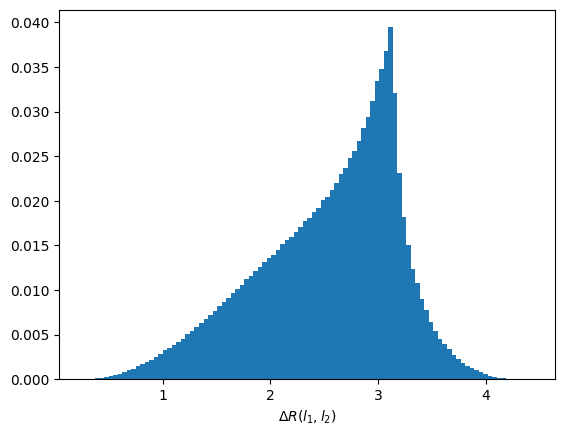

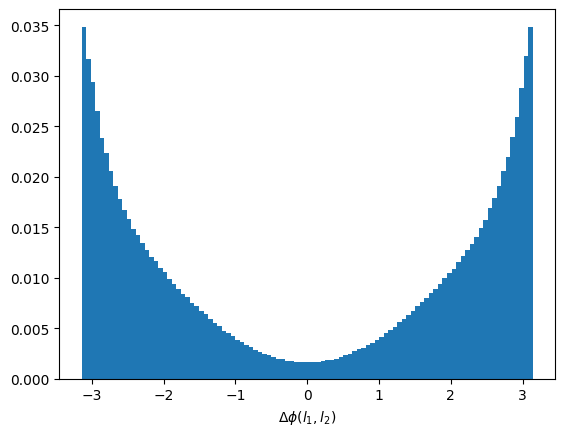

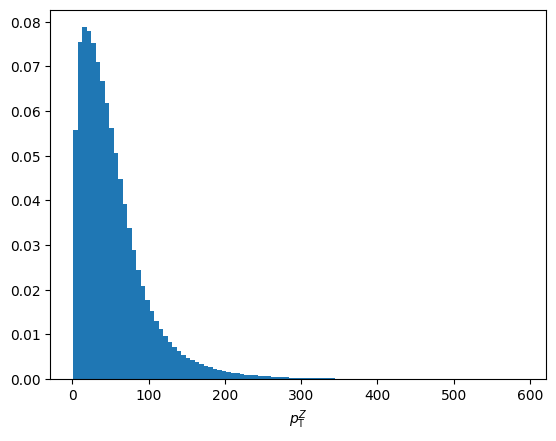

In [27]:
Z = (l1+l2)

plt.hist(l1.deltaR(l2), weights = events.weights, bins=100)
plt.xlabel('$\\Delta R(l_1, l_2)$')
plt.show()

plt.hist(l1.deltaphi(l2), weights = events.weights, bins=100)
plt.xlabel('$\\Delta \\phi(l_1, l_2)$')
plt.show()

plt.hist(Z.pt, weights = events.weights, bins=100)
plt.xlabel('$p_{\\mathrm{T}}^{Z}$')
plt.show()

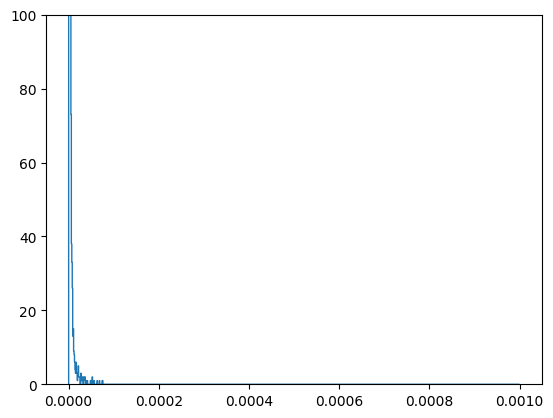

In [8]:
plt.hist(events.weights, bins=1000, range=[0,0.001], histtype='step', label='weights')
plt.ylim(0,100)
plt.show()